<h1 style="color:purple;">Entrenamiento de CNN con Smoothness Regularization en su función de pérdida.</h1>
<p> Valentina Arce España <p>
<p> Marzo 2026 <p>

<div class="alert alert-block alert-warning">
Versión 4: Se reemplaza la función LINEX por una <b>Smoothness Regularization</b> sobre las predicciones.<br><br>
La función de pérdida es:<br>
<code>L = MSE(h, y)  +  λ · (1/(m-1)) · dh^T · dh</code><br><br>
Donde <code>dh = h[1:] - h[:-1]</code> es la diferencia entre predicciones de ciclos consecutivos del mismo motor.
El objetivo es penalizar cambios bruscos entre ciclos, reduciendo el ruido en la curva de RUL predicha.<br><br>
<b>Requisito clave:</b> Los datos DEBEN estar ordenados por (unidad, ciclo) y el entrenamiento usa <code>shuffle=False</code>.
</div>

In [3]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import tensorflow as tf
from tensorflow.keras import layers, models
import tensorflow.keras.backend as K
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import load_model

# ==========================================
# 1. CONFIGURACION
# ==========================================
filename     = 'N-CMAPSS_DS08a-009.h5'
WINDOW_SIZE  = 50
BATCH_SIZE   = 512
EPOCHS       = 15
TRAIN_RATIO  = 0.8
WINDOW_STEP  = 10

print('Configuracion cargada.')

Configuracion cargada.


In [4]:
# ==========================================
# 2. CARGA DE DATOS
# ==========================================
def load_data(filepath):
    with h5py.File(filepath, 'r') as hdf:
        W_dev     = np.array(hdf.get('W_dev'))
        X_s_dev   = np.array(hdf.get('X_s_dev'))
        X_v_dev   = np.array(hdf.get('X_v_dev'))
        Y_dev     = np.array(hdf.get('Y_dev'))
        A_dev     = np.array(hdf.get('A_dev'))

        W_test    = np.array(hdf.get('W_test'))
        X_s_test  = np.array(hdf.get('X_s_test'))
        X_v_test  = np.array(hdf.get('X_v_test'))
        Y_test    = np.array(hdf.get('Y_test'))
        A_test    = np.array(hdf.get('A_test'))

        A_var_raw = np.array(hdf.get('A_var'))
        A_var     = list(np.array(A_var_raw, dtype='U20'))

    return (W_dev, X_s_dev, X_v_dev, Y_dev, A_dev), \
           (W_test, X_s_test, X_v_test, Y_test, A_test), A_var

print('Cargando datos...')
(train_W, train_Xs, train_Xv, train_Y, train_A), \
(test_W,  test_Xs,  test_Xv,  test_Y,  test_A), A_var = load_data(filename)

print(f'A_var (columnas de A): {A_var}')
print('Datos cargados correctamente.')

Cargando datos...
A_var (columnas de A): [np.str_('unit'), np.str_('cycle'), np.str_('Fc'), np.str_('hs')]
Datos cargados correctamente.


In [5]:
# ==========================================
# 3. REDUCCION DE MOTORES (TRAIN)
# ==========================================
train_units      = np.unique(train_A[:, 0])
n_units_original = len(train_units)
n_units_keep     = int(n_units_original * TRAIN_RATIO) 
keep_units       = train_units[:n_units_keep]

print(f'Reduciendo dataset: usando {n_units_keep} de {n_units_original} motores.')

mask_train = np.isin(train_A[:, 0], keep_units)
train_W  = train_W[mask_train]
train_Xs = train_Xs[mask_train]
train_Xv = train_Xv[mask_train]
train_Y  = train_Y[mask_train]
train_A  = train_A[mask_train]

print(f'Motores en entrenamiento: {np.unique(train_A[:, 0])}')

Reduciendo dataset: usando 7 de 9 motores.
Motores en entrenamiento: [1. 2. 3. 4. 5. 6. 7.]


In [6]:
# ==========================================
# 4. PREPROCESAMIENTO Y ESCALADO
# ==========================================
X_train = np.concatenate((train_W, train_Xs, train_Xv), axis=1)
X_test  = np.concatenate((test_W,  test_Xs,  test_Xv),  axis=1)

scaler         = MinMaxScaler(feature_range=(-1, 1))
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Forma X_train (reducido): {X_train_scaled.shape}')
print(f'Forma X_test:             {X_test_scaled.shape}')

Forma X_train (reducido): (3911368, 32)
Forma X_test:             (3722997, 32)


In [7]:
# ==========================================
# 5. GENERACION DE VENTANAS
# ==========================================
# IMPORTANTE: cycle_col_index=1 asume A_var[1] = 'cycle'.
# Ajusta si el print de A_var muestra un orden distinto.

def create_windows_with_meta(X, y, A, window_size, step=1,
                             unit_col_index=0, cycle_col_index=1):
    unique_units = np.unique(A[:, unit_col_index])
    X_windows, y_windows, meta = [], [], []

    for unit in unique_units:
        idx    = np.where(A[:, unit_col_index] == unit)[0]
        unit_X = X[idx, :]
        unit_y = y[idx]
        unit_A = A[idx]

        n = len(unit_X)
        if n < window_size:
            continue

        for i in range(0, n - window_size + 1, step):
            X_windows.append(unit_X[i : i + window_size, :])
            y_windows.append(unit_y[i + window_size - 1])
            meta.append((unit, unit_A[i + window_size - 1, cycle_col_index]))

    return np.array(X_windows), np.array(y_windows), np.array(meta)


print(f'Generando ventanas de entrenamiento (Step={WINDOW_STEP})...')
X_train_w, y_train_w, train_meta = create_windows_with_meta(
    X_train_scaled, train_Y, train_A, WINDOW_SIZE, step=WINDOW_STEP
)

print('Generando ventanas de test (Step=10)...')
X_test_w, y_test_w, test_meta = create_windows_with_meta(
    X_test_scaled, test_Y, test_A, WINDOW_SIZE, step=10
)

# Ordenar train por (unit, ciclo) --- CRITICO para que dh sea valido
sort_idx   = np.lexsort((train_meta[:, 1], train_meta[:, 0]))
X_train_w  = X_train_w[sort_idx]
y_train_w  = y_train_w[sort_idx]
train_meta = train_meta[sort_idx]

print(f'Input Shape Train: {X_train_w.shape}')
print(f'Input Shape Test:  {X_test_w.shape}')
print(f'Primeras 5 ventanas (unit, ciclo_fin): {train_meta[:5]}')
print(f'Ultimas  5 ventanas (unit, ciclo_fin): {train_meta[-5:]}')

Generando ventanas de entrenamiento (Step=10)...
Generando ventanas de test (Step=10)...
Input Shape Train: (391104, 50, 32)
Input Shape Test:  (372274, 50, 32)
Primeras 5 ventanas (unit, ciclo_fin): [[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]]
Ultimas  5 ventanas (unit, ciclo_fin): [[ 7. 68.]
 [ 7. 68.]
 [ 7. 68.]
 [ 7. 68.]
 [ 7. 68.]]


In [8]:
# ==========================================
# 6. ARQUITECTURA CNN
# ==========================================
input_shape = (X_train_w.shape[1], X_train_w.shape[2])

model = models.Sequential([
    layers.Conv1D(64,  3, activation='relu', input_shape=input_shape, padding='same'),
    layers.Conv1D(64,  3, activation='relu', padding='same'),
    layers.MaxPooling1D(2),
    layers.Conv1D(128, 5, activation='relu', padding='same'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(64,  activation='relu'),
    layers.Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.summary()

c:\Users\aulasingenieria\Documents\Tina\tesis-env\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 50, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 50, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 25, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 25, 128)        │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       409,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 477,697 (1.82 MB)

 Trainable params: 477,697 (1.82 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# ==========================================
# 7. ENTRENAMIENTO FASE 1 --- MSE PURO
# ==========================================
print('Iniciando entrenamiento con MSE puro...')
history_mse = model.fit(
    X_train_w, y_train_w,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    verbose=1
)
print('Entrenamiento MSE finalizado.')

Iniciando entrenamiento con MSE puro...
Epoch 1/15
688/688 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - loss: 119.2503 - val_loss: 21.9017
Epoch 2/15
688/688 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - loss: 50.3192 - val_loss: 15.9193
Epoch 3/15
688/688 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - loss: 46.3393 - val_loss: 18.5749
Epoch 4/15
688/688 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - loss: 41.9278 - val_loss: 30.7237
Epoch 5/15
688/688 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - loss: 39.9244 - val_loss: 24.3756
Epoch 6/15
688/688 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - loss: 38.6142 - val_loss: 15.5187
Epoch 7/15
688/688 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - loss: 37.8102 - val_loss: 17.8652
Epoch 8/15
688/688 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - loss: 35.6509 - val_loss: 18.7211
Epoch 9/15
688/688 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - loss: 35.4570 - val_loss: 13.1337
Epoch 10/15
688/688 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - loss: 33.8957 - val_loss: 19.5754
Epoch 11/15
688/688 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - l

Prediciendo con modelo MSE...
RMSE baseline (MSE puro): 9.5108
Bias baseline (MSE puro): -6.3471


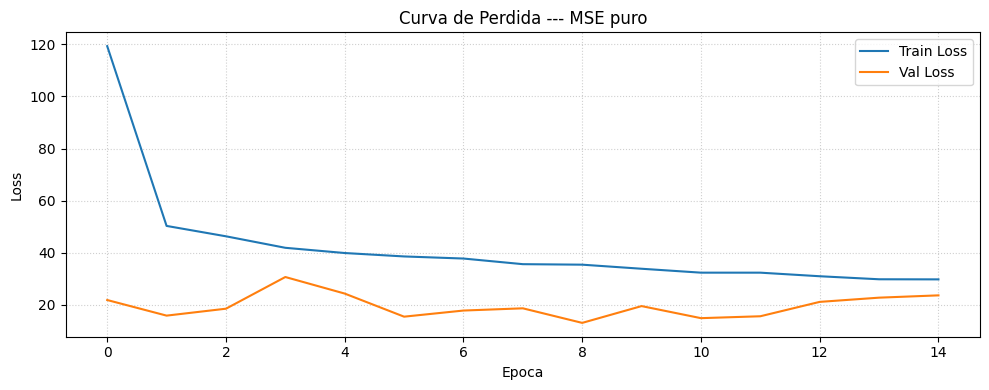

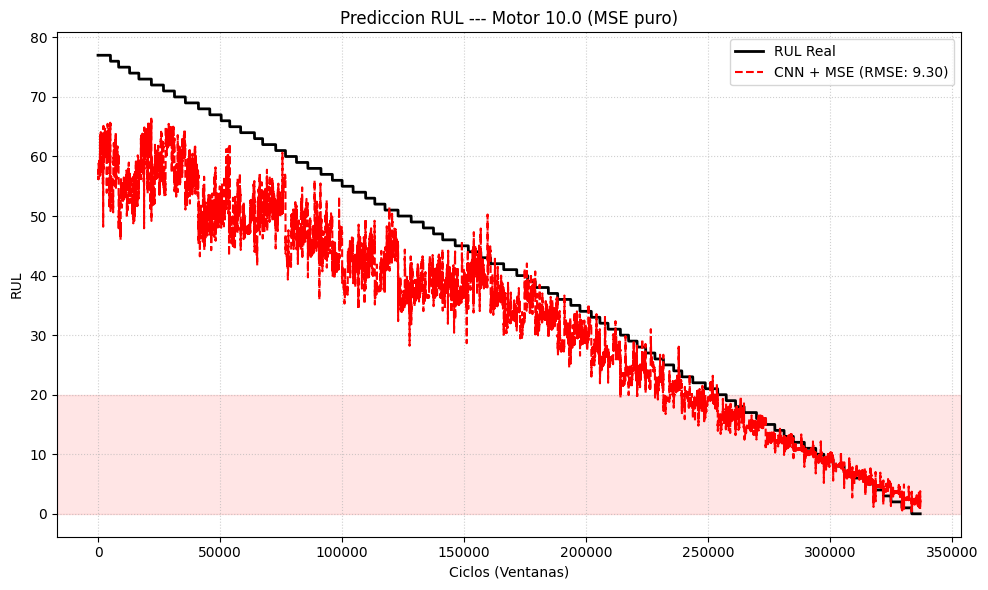

In [10]:
# ==========================================
# 8. EVALUACION BASELINE --- MODELO MSE
# ==========================================
print('Prediciendo con modelo MSE...')
y_pred_mse = model.predict(X_test_w, verbose=0).flatten()  # flatten para evitar broadcast
rmse_base  = np.sqrt(mean_squared_error(y_test_w, y_pred_mse))
bias_base  = np.mean(y_test_w.flatten() - y_pred_mse)

print(f'RMSE baseline (MSE puro): {rmse_base:.4f}')
print(f'Bias baseline (MSE puro): {bias_base:.4f}')

# Curva de perdida
plt.figure(figsize=(10, 4))
plt.plot(history_mse.history['loss'],     label='Train Loss')
plt.plot(history_mse.history['val_loss'], label='Val Loss')
plt.title('Curva de Perdida --- MSE puro')
plt.xlabel('Epoca')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# Grafica primer motor de test
target_unit  = np.unique(test_A[:, 0])[0]
idx_unit     = np.where(test_A[:, 0] == target_unit)[0]
X_u, y_u, _ = create_windows_with_meta(
    X_test_scaled[idx_unit], test_Y[idx_unit], test_A[idx_unit], WINDOW_SIZE, step=1
)
y_u_pred_mse = model.predict(X_u, verbose=0).flatten()
y_u_flat     = y_u.flatten()

plt.figure(figsize=(10, 6))
plt.plot(y_u_flat, label='RUL Real', color='black', linewidth=2)
plt.plot(y_u_pred_mse, label=f'CNN + MSE (RMSE: {np.sqrt(mean_squared_error(y_u_flat, y_u_pred_mse)):.2f})',
         color='red', linestyle='--', linewidth=1.5)
plt.axhspan(0, 20, color='red', alpha=0.1)
plt.title(f'Prediccion RUL --- Motor {target_unit} (MSE puro)')
plt.xlabel('Ciclos (Ventanas)')
plt.ylabel('RUL')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# 9. GUARDAR MODELO MSE
# ==========================================
model.save('modelo_mse_v4_MoreMotors.keras')
print("Modelo MSE guardado como 'modelo_mse_v4_MoreMotors.keras'")

Modelo MSE guardado como 'modelo_mse_v4_MoreTrain.keras'


In [12]:
# ==========================================
# 10. FUNCION DE PERDIDA: MSE + SMOOTHNESS
# ==========================================
#
# L = MSE(h, y)  +  lambda * (1/(m-1)) * dh^T * dh
#
# dh = h[1:] - h[:-1]  (diferencias entre predicciones de ciclos consecutivos)
# Funciona correctamente porque:
#   - Los datos estan ordenados por (unit, ciclo)  <-- hecho en celda 5
#   - El entrenamiento usa shuffle=False           <-- aplicado en celda 11

LAMBDA_S = 1e-9  # Rango sugerido: [0.001, 0.1]
                 # Si RMSE sube mucho -> bajar a 0.001
                 # Si la curva sigue ruidosa -> subir a 0.05

def mse_smoothness_loss(y_true, y_pred):
    # Termino 1: MSE estandar
    mse_term = K.mean(K.square(y_true - y_pred))

    # Termino 2: Suavidad entre predicciones consecutivas
    # dh tiene forma (batch_size - 1,)
    dh = y_pred[1:] - y_pred[:-1]
    # K.mean(dh^2) = (1/(m-1)) * dh^T * dh
    smoothness_term = K.mean(K.square(dh))

    return mse_term + LAMBDA_S * smoothness_term

print(f'Funcion de perdida definida con lambda = {LAMBDA_S}')

Funcion de perdida definida con lambda = 1e-09


In [13]:
# ==========================================
# 11. FINE-TUNING FASE 2 --- MSE + SMOOTHNESS
# ==========================================
model_smooth = load_model('modelo_mse_v4.keras')

model_smooth.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss=mse_smoothness_loss
)
print('Modelo compilado con MSE + Smoothness.')

# CRITICO: shuffle=False para que dh corresponda a ciclos consecutivos
print('Iniciando Fine-Tuning...')
history_smooth = model_smooth.fit(
    X_train_w, y_train_w,
    epochs=15,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    shuffle=False,
    verbose=1
)
print('Fine-Tuning finalizado!')

Modelo compilado con MSE + Smoothness.
Iniciando Fine-Tuning...
Epoch 1/15
688/688 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - loss: 464.9052 - val_loss: 734.3060
Epoch 2/15
688/688 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - loss: 370.5324 - val_loss: 712.7485
Epoch 3/15
688/688 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - loss: 373.4427 - val_loss: 629.5923
Epoch 4/15
688/688 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - loss: 353.2619 - val_loss: 595.1026
Epoch 5/15
688/688 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - loss: 351.7127 - val_loss: 569.4653
Epoch 6/15
688/688 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - loss: 345.2265 - val_loss: 648.4643
Epoch 7/15
688/688 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - loss: 326.2652 - val_loss: 603.0857
Epoch 8/15
688/688 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - loss: 313.1784 - val_loss: 616.5181
Epoch 9/15
688/688 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - loss: 304.0759 - val_loss: 599.8627
Epoch 10/15
688/688 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - loss: 292.0316 - val_loss: 553.5669
Epoch 11/15
688

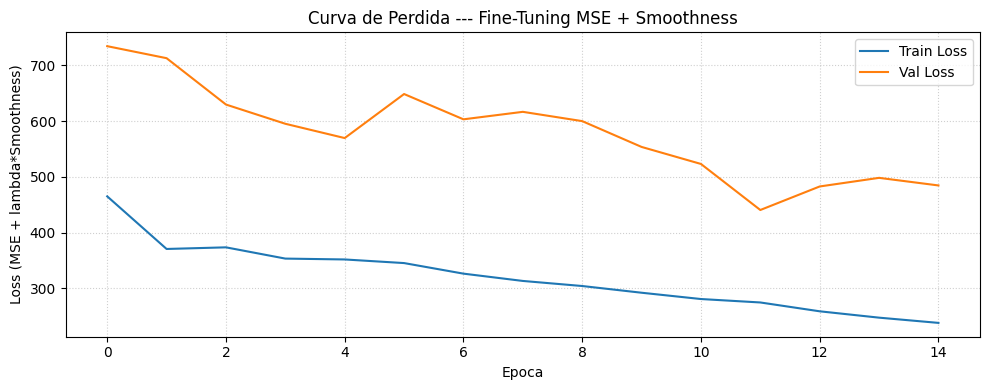

In [14]:
# ==========================================
# 12. CURVA DE PERDIDA --- FINE-TUNING
# ==========================================
plt.figure(figsize=(10, 4))
plt.plot(history_smooth.history['loss'],     label='Train Loss')
plt.plot(history_smooth.history['val_loss'], label='Val Loss')
plt.title('Curva de Perdida --- Fine-Tuning MSE + Smoothness')
plt.xlabel('Epoca')
plt.ylabel('Loss (MSE + lambda*Smoothness)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

In [15]:
# ==========================================
# 13. COMPARATIVA GLOBAL --- MSE vs MSE+SMOOTHNESS
# ==========================================
y_pred_mse    = model.predict(X_test_w,       verbose=0).flatten()
y_pred_smooth = model_smooth.predict(X_test_w, verbose=0).flatten()
y_test_flat   = y_test_w.flatten()

rmse_mse    = np.sqrt(mean_squared_error(y_test_flat, y_pred_mse))
rmse_smooth = np.sqrt(mean_squared_error(y_test_flat, y_pred_smooth))
bias_mse    = np.mean(y_test_flat - y_pred_mse)
bias_smooth = np.mean(y_test_flat - y_pred_smooth)
std_mse     = np.std(np.diff(y_pred_mse))
std_smooth  = np.std(np.diff(y_pred_smooth))

print('============================================')
print('        COMPARATIVA GLOBAL EN TEST          ')
print('============================================')
print(f'{"Modelo":<22} {"RMSE":>8} {"Bias":>8} {"Std(dh)":>10}')
print('-' * 50)
print(f'{"MSE puro":<22} {rmse_mse:>8.4f} {bias_mse:>8.4f} {std_mse:>10.4f}')
print(f'{"MSE + Smoothness":<22} {rmse_smooth:>8.4f} {bias_smooth:>8.4f} {std_smooth:>10.4f}')
print('============================================')
print('Std(dh): menor valor = curvas de RUL mas suaves.')

        COMPARATIVA GLOBAL EN TEST          
Modelo                     RMSE     Bias    Std(dh)
--------------------------------------------------
MSE puro                 9.5108  -6.3471     0.5029
MSE + Smoothness        22.7968 -16.7784     0.3390
Std(dh): menor valor = curvas de RUL mas suaves.


Generando comparativa para el Motor 10.0...


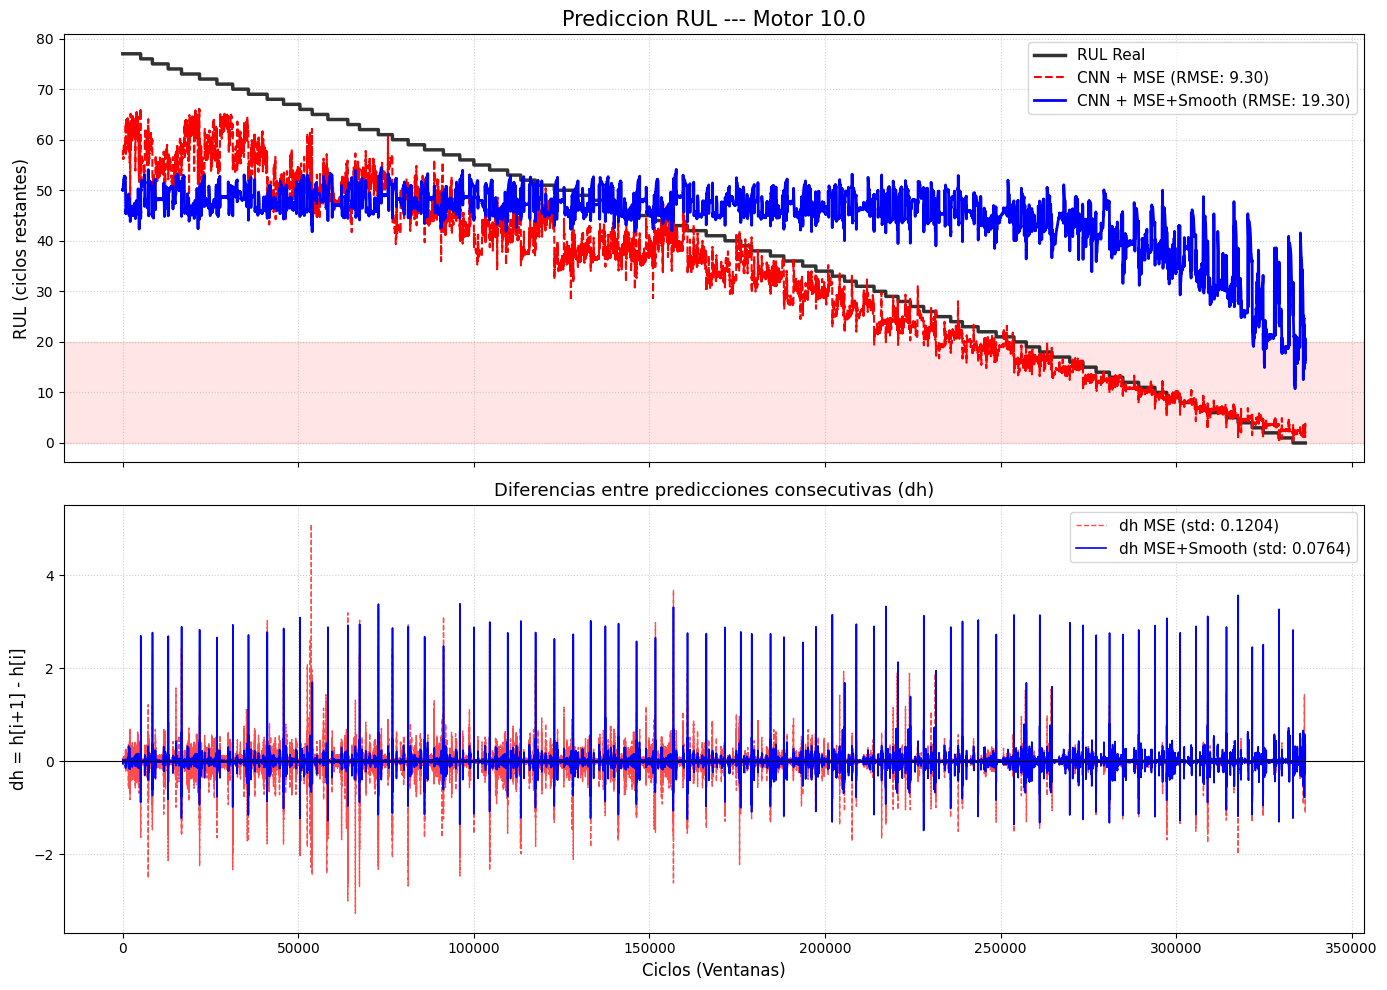

In [16]:
# ==========================================
# 14. COMPARATIVA POR MOTOR
# ==========================================
def comparar_motores(unit_id):
    idx = np.where(test_A[:, 0] == unit_id)[0]
    if len(idx) == 0:
        print(f'Motor {unit_id} no encontrado en el set de test.')
        return

    print(f'Generando comparativa para el Motor {unit_id}...')
    X_u, y_u, _ = create_windows_with_meta(
        X_test_scaled[idx], test_Y[idx], test_A[idx], WINDOW_SIZE, step=1
    )

    pred_mse_u    = model.predict(X_u,        verbose=0).flatten()
    pred_smooth_u = model_smooth.predict(X_u,  verbose=0).flatten()

    rmse_mse_u    = np.sqrt(mean_squared_error(y_u, pred_mse_u))
    rmse_smooth_u = np.sqrt(mean_squared_error(y_u, pred_smooth_u))

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

    ax1.plot(y_u, label='RUL Real', color='black', linewidth=2.5, alpha=0.8)
    ax1.plot(pred_mse_u,    label=f'CNN + MSE (RMSE: {rmse_mse_u:.2f})',
             color='red',  linestyle='--', linewidth=1.5)
    ax1.plot(pred_smooth_u, label=f'CNN + MSE+Smooth (RMSE: {rmse_smooth_u:.2f})',
             color='blue', linewidth=2)
    ax1.axhspan(0, 20, color='red', alpha=0.1)
    ax1.set_title(f'Prediccion RUL --- Motor {unit_id}', fontsize=15)
    ax1.set_ylabel('RUL (ciclos restantes)', fontsize=12)
    ax1.legend(fontsize=11)
    ax1.grid(True, linestyle=':', alpha=0.6)

    dh_mse    = np.diff(pred_mse_u)
    dh_smooth = np.diff(pred_smooth_u)
    ax2.plot(dh_mse,    label=f'dh MSE (std: {np.std(dh_mse):.4f})',
             color='red',  linestyle='--', linewidth=1, alpha=0.7)
    ax2.plot(dh_smooth, label=f'dh MSE+Smooth (std: {np.std(dh_smooth):.4f})',
             color='blue', linewidth=1.2)
    ax2.axhline(0, color='black', linewidth=0.8)
    ax2.set_title('Diferencias entre predicciones consecutivas (dh)', fontsize=13)
    ax2.set_xlabel('Ciclos (Ventanas)', fontsize=12)
    ax2.set_ylabel('dh = h[i+1] - h[i]', fontsize=12)
    ax2.legend(fontsize=11)
    ax2.grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout()
    plt.show()


target_unit = np.unique(test_A[:, 0])[0]
comparar_motores(target_unit)

# Descomenta para ver otros motores:
# comparar_motores(np.unique(test_A[:, 0])[1])
# comparar_motores(np.unique(test_A[:, 0])[2])

In [17]:
# ==========================================
# 15. GUARDAR MODELO FINAL
# ==========================================
model_smooth.save('modelo_mse_smoothness_v4_MoreTrain.keras')
print("Modelo MSE + Smoothness guardado como 'modelo_mse_smoothness_v4.keras'")

Modelo MSE + Smoothness guardado como 'modelo_mse_smoothness_v4.keras'


Iniciando búsqueda de hiperparámetros para LAMBDA_S...

--- Entrenando con LAMBDA_S = 0.0001 ---
Resultados para λ=0.0001 -> RMSE: 14.09 | Std(dh) (Ruido): 0.2312

--- Entrenando con LAMBDA_S = 0.0005 ---
Resultados para λ=0.0005 -> RMSE: 16.06 | Std(dh) (Ruido): 0.1819

--- Entrenando con LAMBDA_S = 0.001 ---
Resultados para λ=0.001 -> RMSE: 22.98 | Std(dh) (Ruido): 0.2138

--- Entrenando con LAMBDA_S = 0.005 ---
Resultados para λ=0.005 -> RMSE: 14.85 | Std(dh) (Ruido): 0.2132

--- Entrenando con LAMBDA_S = 0.01 ---
Resultados para λ=0.01 -> RMSE: 14.82 | Std(dh) (Ruido): 0.2310



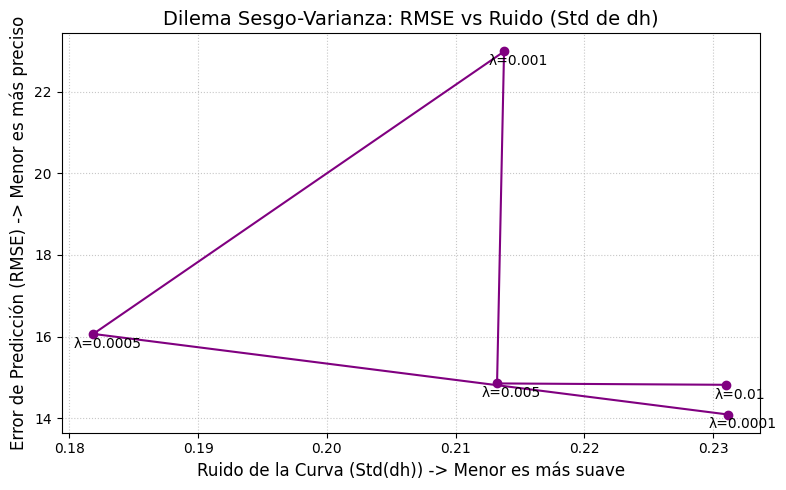

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import tensorflow as tf
from tensorflow.keras import backend as K

# 1. Definir los valores de Lambda a explorar
lambda_values = [0.0001, 0.0005, 0.001, 0.005, 0.01]

resultados_rmse = []
resultados_std_dh = []

print("Iniciando búsqueda de hiperparámetros para LAMBDA_S...\n")

for lam in lambda_values:
    print(f"--- Entrenando con LAMBDA_S = {lam} ---")
    
    # 2. Redefinir la función de pérdida con el lambda actual
    def custom_smoothness_loss_search(y_true, y_pred):
        # Error cuadrático medio estándar
        mse = K.mean(K.square(y_true - y_pred))
        
        # Penalización Smoothness
        diff = y_pred[1:] - y_pred[:-1]
        smooth_penalty = K.mean(K.square(diff))
        
        return mse + (lam * smooth_penalty)

    # 3. Clonar el modelo base (para no sobreescribir pesos anteriores en cada iteración)
    # Asumo que tu modelo base se llama 'model' o 'model_base'. 
    # Sustituye 'model' por el nombre de tu arquitectura original sin compilar.
    model_temp = tf.keras.models.clone_model(model)
    model_temp.set_weights(model.get_weights()) # Partimos de los mismos pesos iniciales/pre-entrenados
    
    model_temp.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4), 
                       loss=custom_smoothness_loss_search)
    
    # 4. Entrenar el modelo (ajusta epochs y batch_size según tu hardware)
    # NOTA: Asegúrate de mantener shuffle=False como requiere tu regularización
    # 4. Entrenar el modelo utilizando las ventanas espaciotemporales correctas
    model_temp.fit(X_train_w, y_train_w, 
                   epochs=5, # Usamos pocos epochs para el barrido rápido
                   batch_size=256, 
                   shuffle=False, 
                   verbose=0)
    
    # 5. Predecir y calcular métricas en test
    y_pred_temp = model_temp.predict(X_test_w, verbose=0).flatten()
    y_test_flat = y_test_w.flatten()
    
    # Cálculo de métricas
    rmse = np.sqrt(mean_squared_error(y_test_flat, y_pred_temp))
    std_dh = np.std(np.diff(y_pred_temp))
    
    resultados_rmse.append(rmse)
    resultados_std_dh.append(std_dh)
    
    print(f"Resultados para λ={lam} -> RMSE: {rmse:.2f} | Std(dh) (Ruido): {std_dh:.4f}\n")

# ==========================================
# 6. GRAFICAR EL TRADE-OFF (Frente de Pareto)
# ==========================================
plt.figure(figsize=(8, 5))
plt.plot(resultados_std_dh, resultados_rmse, marker='o', linestyle='-', color='purple')

# Anotar los valores de lambda en cada punto
for i, lam in enumerate(lambda_values):
    plt.annotate(f"λ={lam}", 
                 (resultados_std_dh[i], resultados_rmse[i]),
                 textcoords="offset points", 
                 xytext=(10,-10), 
                 ha='center')

plt.title('Dilema Sesgo-Varianza: RMSE vs Ruido (Std de dh)', fontsize=14)
plt.xlabel('Ruido de la Curva (Std(dh)) -> Menor es más suave', fontsize=12)
plt.ylabel('Error de Predicción (RMSE) -> Menor es más preciso', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()